# Modelado de Remesas Familiares — El Salvador (1991–2025)

**Maestría en Análisis y Visualización de Datos Masivos - Universidad Internacional de La Rioja**

**Proyecto:** Predicción del volumen mensual de remesas familiares hacia El Salvador mediante modelos de machine learning e identificación de factores macroeconómicos determinantes (1991-2025).

**Período de análisis:** enero de 1991 – diciembre de 2025

**Equipo:** 1B
- Kelly Mabel Vílchez González
- Herbert Fernando Ramírez Aguilar

## Estructura del notebook

1. **Bloque 1** — Carga, imputación y preparación del dataset
2. **Bloque 2** — Regresión lineal múltiple como modelo baseline
3. **Bloque 3** — Random Forest
4. **Bloque 4** — XGBoost
5. **Bloque 5** — LSTM
---

> **Nota:** Este notebook continúa el flujo analítico desarrollado en el notebook de análisis exploratorio de datos (EDA). Para su ejecución, el archivo `Dataset_Maestro_Final.csv` debe encontrarse en la misma carpeta que este notebook.

In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# Se importan aquí todas las librerías que se usarán en el
# notebook completo.
# ============================================================

# --- Manipulación de datos ---
import pandas as pd
# pandas: librería principal para trabajar con tablas (DataFrames).
# Se usa para cargar el CSV, filtrar filas, crear columnas nuevas
# y preparar los datos antes de entrenar los modelos.

import numpy as np
# numpy: librería para cálculos matemáticos con arreglos numéricos.
# Se usa internamente por casi todas las librerías de ML.

# --- Visualización ---
import matplotlib.pyplot as plt
# matplotlib: librería estándar para crear gráficos en Python.
# Usaremos plt.subplots() para dibujar las figuras del informe.

import seaborn as sns
# seaborn: librería de visualización estadística construida sobre matplotlib.
# Genera gráficos más estéticos con menos código.
# La usaremos para el heatmap de comparación de modelos.

# --- Escalado de variables ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# StandardScaler: estandariza las variables utilizando la media
# y la desviación estándar.
# Se utiliza en la preparación de algunos modelos del notebook
# y para mantener transformaciones consistentes entre train y test.
# Los modelos basados en árboles no requieren escalado por naturaleza.

# --- Validación cruzada para series de tiempo ---
from sklearn.model_selection import TimeSeriesSplit
# TimeSeriesSplit: versión de validación cruzada que respeta el orden temporal.
# A diferencia del KFold clásico, nunca mezcla datos del futuro
# con datos del pasado. Cada "fold" entrena con datos anteriores
# y valida con datos posteriores, tal como funciona una serie real.

# --- Métricas de evaluación ---
from sklearn.metrics import (
    mean_squared_error,   # MSE: error cuadrático medio
    mean_absolute_error,  # MAE: error absoluto medio
    r2_score              # R²: coeficiente de determinación
)
# Estas tres métricas se calculan igual para todos los modelos,
# lo que hace la comparación final justa y consistente.
# RMSE = raíz cuadrada del MSE (misma unidad que la variable objetivo)
# MAE  = promedio del valor absoluto de los errores
# R² = coeficiente de determinación; un valor de 1 indica ajuste
# perfecto, 0 equivale al desempeño de la referencia basada en
# la media y puede tomar valores negativos.
# MAPE = error porcentual absoluto medio (calculado manualmente abajo)

# --- Modelo 1: Regresión lineal ---
from sklearn.linear_model import LinearRegression
# LinearRegression: implementación de scikit-learn de la regresión lineal múltiple.
# Es el modelo más simple del estudio y actúa como referencia (baseline).
# Actúa como modelo de referencia (baseline) para evaluar si
# los métodos más complejos aportan mejoras predictivas.

# --- VIF para multicolinealidad ---
from statsmodels.stats.outliers_influence import variance_inflation_factor
# variance_inflation_factor: calcula el Factor de Inflación de la Varianza.
# Un VIF alto (>10) indica que esa variable está siendo "explicada"
# por otras variables del modelo, lo que causa multicolinealidad.
# La revisamos antes de interpretar los coeficientes de la regresión.

# --- Modelo 2: Random Forest ---
from sklearn.ensemble import RandomForestRegressor
# RandomForestRegressor: entrena muchos árboles de decisión en paralelo
# y promedia sus predicciones. Es robusto frente a outliers y permite
# conocer la importancia de cada variable.

# --- Modelo 3: XGBoost ---
from xgboost import XGBRegressor
# XGBRegressor: implementación de XGBoost para regresión.
# Construye árboles secuencialmente, donde cada árbol corrige
# los errores del anterior. Permite modelar relaciones no lineales mediante una estrategia
# secuencial de boosting y mecanismos de regularización.

# --- Modelo 4: LSTM ---
import tensorflow as tf
# tensorflow: librería de deep learning de Google.
# Es el motor que ejecuta los cálculos del modelo LSTM.

from tensorflow.keras.models import Sequential
# Sequential: permite construir una red neuronal capa por capa,
# como si apiláramos bloques. Es el tipo de modelo más sencillo en Keras.

from tensorflow.keras.layers import LSTM, Dense, Dropout
# LSTM: capa de memoria a largo/corto plazo. Es el núcleo del modelo.
#   Aprende dependencias temporales en secuencias históricas.
# Dense: capa completamente conectada (fully connected).
#   Se usa al final del LSTM para producir el valor de predicción.
# Dropout: técnica de regularización que "apaga" aleatoriamente
#   una fracción de neuronas durante el entrenamiento para evitar
#   que el modelo memorice los datos en lugar de aprender patrones.

from tensorflow.keras.callbacks import EarlyStopping
# EarlyStopping: detiene el entrenamiento del LSTM automáticamente
# si la pérdida en validación deja de mejorar.
# Esto puede reducir el riesgo de sobreajuste y evitar
# épocas adicionales sin mejora en la validación.

# --- Suprimir advertencias ---
import warnings
warnings.filterwarnings('ignore')
# Oculta advertencias de deprecación que no afectan los resultados.

import os
# os: librería estándar para interactuar con el sistema de archivos.
# Se usa para crear la carpeta de outputs si no existe.

# --- Semilla aleatoria global ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Fijar semillas reduce la variabilidad asociada a componentes
# aleatorios y favorece la reproducibilidad de los experimentos.
# No garantiza resultados idénticos entre distintas versiones,
# sistemas operativos, dispositivos o configuraciones de hardware.
# Sin esto, Random Forest, XGBoost y LSTM producen resultados
# ligeramente distintos en cada ejecución porque tienen
# componentes aleatorios internos.
# El valor 42 es una convención en la comunidad de ciencia de datos.

# --- Configuración visual ---
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")
# Se mantiene el mismo estilo visual que el notebook del EDA
# para coherencia visual en todos los gráficos del proyecto.

print("Librerías importadas correctamente.")
print(f"  TensorFlow versión: {tf.__version__}")

Librerías importadas correctamente.
  TensorFlow versión: 2.20.0


In [3]:
# ============================================================
# 2. CARPETA DE OUTPUTS Y CARGA DEL DATASET
# ============================================================
# Esta celda hace:
#   1. Detecta la raíz del proyecto y configura las rutas
#   2. Crea la carpeta donde se guardarán los resultados
#   3. Carga el CSV con el dataset maestro
#   4. Aplica la imputación de deportaciones (idéntica al EDA)
# ============================================================

# ----------------------------------------------------------
# PASO 1: Configurar rutas del proyecto
# ----------------------------------------------------------
from pathlib import Path

# Detectar automáticamente la raíz del proyecto.
# Funciona tanto si el notebook se ejecuta desde la raíz
# como desde la carpeta notebooks/.
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "No se encontró la carpeta 'data'. "
        "Ejecute el notebook desde la raíz del proyecto "
        "o desde la carpeta 'notebooks'."
    )

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_MODELADO = PROJECT_ROOT / 'outputs_modelado'

# Crear carpeta de outputs si no existe
OUTPUTS_MODELADO.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Carpeta de datos: {DATA_DIR}")
print(f"Carpeta de outputs de modelado: {OUTPUTS_MODELADO}")

# ----------------------------------------------------------
# PASO 2: Cargar el dataset maestro
# ----------------------------------------------------------
df = pd.read_csv(
    DATA_DIR / 'Dataset_Maestro_Final.csv',
    parse_dates=['Fecha'],   # Interpreta la columna 'Fecha' como fecha real
    index_col='Fecha'        # Establece 'Fecha' como índice del DataFrame
)
# El índice de tipo fecha es esencial para trabajar con series de tiempo.
# Permite filtrar por períodos (ej: df['2020':]) y respetar el orden temporal.

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"  Período: {df.index.min().strftime('%B %Y')} → {df.index.max().strftime('%B %Y')}")

# ----------------------------------------------------------
# PASO 3: Imputación de deportaciones (misma lógica del EDA)
# ----------------------------------------------------------
# La variable Deportaciones_Total tiene faltantes en:
#   - 1991 (12 meses): el DHS no tiene datos para ese año.
#   - 2023, 2024, 2025 (36 meses): datos aún no publicados.
# Se imputan con promedios de años adyacentes disponibles,
# declarado como supuesto metodológico en la sección 5.3.1.

# Columna auxiliar con el año para facilitar el filtrado
df['Año'] = df.index.year

# CASO 1: 1991 → usar promedio de 1992
valor_1992 = df[df['Año'] == 1992]['Deportaciones_Total'].mean()
df.loc[df['Año'] == 1991, 'Deportaciones_Total'] = valor_1992

# CASO 2: 2023-2025 → usar promedio de 2020-2022
media_reciente = df[df['Año'].isin([2020, 2021, 2022])]['Deportaciones_Total'].mean()
df.loc[df['Año'].isin([2023, 2024, 2025]), 'Deportaciones_Total'] = media_reciente

# Eliminar columna auxiliar: ya no se necesita
df = df.drop(columns=['Año'])

# Verificar que no quedaron faltantes en deportaciones
faltantes_dep = df['Deportaciones_Total'].isnull().sum()
print(f" Imputación de deportaciones aplicada.")
print(f"  Faltantes restantes en Deportaciones_Total: {faltantes_dep}")

# ----------------------------------------------------------
# PASO 4: Verificación general de faltantes
# ----------------------------------------------------------
nulos = df.isnull().sum()
nulos_con_valor = nulos[nulos > 0]

print(f"\n--- Faltantes por variable ---")
print(nulos_con_valor)
print("\nNota: Los faltantes en Remesas_Lag son estructurales.")
print("No existen meses previos a enero 1991. Se manejan en la preparación de features.")

Raíz del proyecto: C:\Users\kmabe\TFM
Carpeta de datos: C:\Users\kmabe\TFM\data
Carpeta de outputs de modelado: C:\Users\kmabe\TFM\outputs_modelado
Dataset cargado: 420 filas × 15 columnas
  Período: January 1991 → December 2025
 Imputación de deportaciones aplicada.
  Faltantes restantes en Deportaciones_Total: 0

--- Faltantes por variable ---
Remesas_Lag1      1
Remesas_Lag2      2
Remesas_Lag3      3
Remesas_Lag12    12
dtype: int64

Nota: Los faltantes en Remesas_Lag son estructurales.
No existen meses previos a enero 1991. Se manejan en la preparación de features.


In [4]:
# ============================================================
# 3. PREPARACIÓN DE FEATURES Y DIVISIÓN
# ============================================================
# Esta celda hace la preparación final antes de entrenar:
#   1. Define cuáles columnas son features (X) y cuál es el target (y)
#   2. Elimina las filas con NaN estructurales (los primeros 12 meses
#      no tienen Remesas_Lag12, así que no se pueden usar)
#   3. Divide el dataset en entrenamiento (1991-2019) y prueba (2020-2025)
#   4. Verifica que la división sea correcta
#
# IMPORTANTE: la división es CRONOLÓGICA, no aleatoria.
# En series de tiempo, mezclar pasado y futuro introduce
# "fuga de información" (data leakage) que infla artificialmente
# los resultados y hace que el modelo parezca mejor de lo que es.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Definir features y target
# ----------------------------------------------------------

# TARGET: la variable que queremos predecir
TARGET = 'Remesas_Millones_USD'

# FEATURES: todas las columnas que el modelo usará para predecir
# Se excluye el target explícitamente para no incluirlo como predictor
FEATURES = [col for col in df.columns if col != TARGET]

print("=== VARIABLES DEL MODELO ===")
print(f"\nTarget (variable a predecir):")
print(f"  → {TARGET}")
print(f"\nFeatures ({len(FEATURES)} variables predictoras):")
for f in FEATURES:
    print(f"  · {f}")

# ----------------------------------------------------------
# PASO 2: Eliminar filas con NaN en Remesas_Lag12
# ----------------------------------------------------------
# Remesas_Lag12 es el rezago más largo: necesita 12 meses de historia.
# Los primeros 12 meses del dataset (ene-dic 1991) no tienen ese valor.
# Esas filas no se pueden usar para entrenar ni evaluar ningún modelo.
# Las eliminamos aquí UNA SOLA VEZ para que todos los modelos
# trabajen con exactamente el mismo conjunto de datos.

df_modelo = df.dropna(subset=['Remesas_Lag12']).copy()
# dropna(subset=[...]): elimina filas donde esa columna tenga NaN.
# .copy(): crea una copia independiente para no modificar el df original.

print(f"\n=== DATASET DESPUÉS DE ELIMINAR FALTANTES ===")
print(f"Observaciones originales : {len(df)}")
print(f"Observaciones eliminadas : {len(df) - len(df_modelo)} (primeros 12 meses sin Lag12)")
print(f"Observaciones disponibles: {len(df_modelo)}")
print(f"Período efectivo         : {df_modelo.index.min().strftime('%B %Y')} → {df_modelo.index.max().strftime('%B %Y')}")

# ----------------------------------------------------------
# PASO 3: División cronológica train / test
# ----------------------------------------------------------
# Entrenamiento: enero 1992 a diciembre 2019
# Prueba       : enero 2020 a diciembre 2025
#
# La fecha de corte es el 31 de diciembre de 2019.
# Todo lo anterior es "pasado conocido" para el modelo.
# Todo lo posterior es "futuro a predecir" en la evaluación.

FECHA_CORTE = '2019-12-31'
# Esta fecha separa entrenamiento de prueba.
# Usar string con formato 'YYYY-MM-DD' funciona directamente
# con índices de tipo DatetimeIndex en pandas.

# --- Separar features y target ---
X = df_modelo[FEATURES]
y = df_modelo[TARGET]
# X: tabla con todas las variables predictoras
# y: serie con los valores reales de remesas que queremos predecir

# --- Dividir en train y test ---
X_train = X[X.index <= FECHA_CORTE]
X_test  = X[X.index >  FECHA_CORTE]
y_train = y[y.index <= FECHA_CORTE]
y_test  = y[y.index >  FECHA_CORTE]
# El operador <= selecciona todo hasta el 31 dic 2019 (inclusive).
# El operador >  selecciona todo desde el 1 ene 2020 en adelante.

# ----------------------------------------------------------
# PASO 4: Verificación de la división
# ----------------------------------------------------------
print("\n=== DIVISIÓN TRAIN / TEST ===")
print(f"\nEntrenamiento:")
print(f"  Período : {X_train.index.min().strftime('%B %Y')} → {X_train.index.max().strftime('%B %Y')}")
print(f"  Filas   : {len(X_train)} observaciones")
print(f"  Porcentaje: {len(X_train)/len(df_modelo)*100:.1f}%")

print(f"\nPrueba (test):")
print(f"  Período : {X_test.index.min().strftime('%B %Y')} → {X_test.index.max().strftime('%B %Y')}")
print(f"  Filas   : {len(X_test)} observaciones")
print(f"  Porcentaje: {len(X_test)/len(df_modelo)*100:.1f}%")

print(f"\nTotal: {len(X_train) + len(X_test)} observaciones")

# Verificación de seguridad: confirmar que no hay solapamiento de fechas
assert X_train.index.max() < X_test.index.min(), \
    "ERROR: hay solapamiento entre train y test. Revisar la fecha de corte."
# assert: si la condición es False, lanza un error con el mensaje indicado.
# Aquí verificamos que el último mes de entrenamiento sea ANTERIOR
# al primer mes de prueba. Si esto falla, hay un error grave en la división.

print("\nVerificación superada: train y test no se solapan.")
print("Bloque 1 completado. Listo para entrenar modelos.")

=== VARIABLES DEL MODELO ===

Target (variable a predecir):
  → Remesas_Millones_USD

Features (14 variables predictoras):
  · Remesas_Lag1
  · Remesas_Lag2
  · Remesas_Lag3
  · Remesas_Lag12
  · Desempleo_Hispano_US
  · Desempleo_General_US
  · Salario_Promedio_US
  · Inflacion_CPI_US
  · PIB_US
  · Inflacion_ES
  · PIB_ES
  · Deportaciones_Total
  · Dummy_Crisis
  · Dummy_Covid

=== DATASET DESPUÉS DE ELIMINAR FALTANTES ===
Observaciones originales : 420
Observaciones eliminadas : 12 (primeros 12 meses sin Lag12)
Observaciones disponibles: 408
Período efectivo         : January 1992 → December 2025

=== DIVISIÓN TRAIN / TEST ===

Entrenamiento:
  Período : January 1992 → December 2019
  Filas   : 336 observaciones
  Porcentaje: 82.4%

Prueba (test):
  Período : January 2020 → December 2025
  Filas   : 72 observaciones
  Porcentaje: 17.6%

Total: 408 observaciones

Verificación superada: train y test no se solapan.
Bloque 1 completado. Listo para entrenar modelos.


In [5]:
# ============================================================
# 4. REGRESION LINEAL — ESCALADO Y VALIDACIÓN CRUZADA
# ============================================================
# Antes de entrenar la regresión lineal hacemos:
#   1. Escalar las variables con StandardScaler
#   2. Evaluar el modelo con validación cruzada temporal (TimeSeriesSplit)
#
# ¿Por qué escalar?
# Las variables predictoras presentan magnitudes y unidades diferentes.
# Por ejemplo, algunas variables macroeconómicas se expresan en
# porcentajes, mientras otras utilizan escalas monetarias mayores.
#
# La regresión lineal puede estimarse sin escalado; sin embargo,
# la estandarización facilita la comparación de coeficientes y
# mantiene una representación numérica homogénea de los predictores.
#
# StandardScaler transforma cada variable utilizando la media
# y desviación estándar estimadas exclusivamente con el conjunto
# de entrenamiento.
#
# ¿Por qué TimeSeriesSplit y no KFold clásico?
# Una validación cruzada convencional puede generar particiones
# inadecuadas para datos temporales si no preserva su orden.
# Esto puede introducir información posterior en el proceso de
# entrenamiento y producir estimaciones optimistas del desempeño.
#
# TimeSeriesSplit conserva el orden cronológico: cada partición
# utiliza observaciones anteriores para entrenar y observaciones
# posteriores para validar.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Escalar las variables
# ----------------------------------------------------------

scaler_X = StandardScaler()
# StandardScaler para las features.
# Lo guardamos en una variable porque necesitamos el mismo objeto
# para transformar X_test más adelante (con los parámetros
# aprendidos del train, nunca recalculados con test).

scaler_y = StandardScaler()
# StandardScaler también para el target.
# El escalado del target mantiene una representación numérica
# homogénea durante el ajuste. Posteriormente, las predicciones
# se transforman nuevamente a millones de USD para su evaluación.

# fit_transform en train: aprende media/std Y transforma en un paso
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
# .values: convierte la Serie de pandas a array de numpy
# .reshape(-1, 1): StandardScaler espera una matriz 2D, no un vector 1D
#   -1 significa "calcula tú cuántas filas hay"
#   1  significa "una sola columna"
# .ravel(): vuelve a aplanar a vector 1D porque LinearRegression
#   espera y como vector, no como matriz

# transform en test: usa los parámetros aprendidos del train
# NUNCA llamar fit_transform en test: contaminaría el experimento
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print("  Escalado completado.")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled : {X_test_scaled.shape}")

# ----------------------------------------------------------
# PASO 2: Validación cruzada con TimeSeriesSplit
# ----------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=5)
# n_splits=5: divide el entrenamiento en 5 bloques consecutivos.
# Bloque 1: entrena con los primeros ~56 meses, valida con los siguientes ~56
# Bloque 2: entrena con los primeros ~112 meses, valida con los siguientes ~56
# ... y así sucesivamente hasta cubrir todo el período de entrenamiento.
# Esto simula cómo el modelo se comportaría en producción,
# donde siempre predice hacia adelante con datos históricos.

modelo_lr = LinearRegression()
# Creamos el objeto del modelo. Aún no está entrenado.

# Listas para guardar las métricas de cada fold
rmse_cv = []
mae_cv  = []
r2_cv   = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    # tscv.split() genera pares de índices (posiciones numéricas, no fechas)
    # train_idx: posiciones de las filas para entrenamiento en este fold
    # val_idx:   posiciones de las filas para validación en este fold
    # enumerate(..., 1): numera los folds desde 1 en lugar de desde 0

    # Separar los datos de este fold
    X_fold_train = X_train_scaled[train_idx]
    X_fold_val   = X_train_scaled[val_idx]
    y_fold_train = y_train_scaled[train_idx]
    y_fold_val   = y_train_scaled[val_idx]

    # Entrenar el modelo con los datos de este fold
    modelo_lr.fit(X_fold_train, y_fold_train)
    # .fit(): ajusta los coeficientes del modelo minimizando
    # la suma de errores cuadráticos entre predicción y valor real.

    # Predecir sobre la parte de validación
    y_pred_fold = modelo_lr.predict(X_fold_val)

    # Calcular métricas en escala original (deshacemos el escalado)
    y_fold_val_orig = scaler_y.inverse_transform(
        y_fold_val.reshape(-1, 1)).ravel()
    y_pred_fold_orig = scaler_y.inverse_transform(
        y_pred_fold.reshape(-1, 1)).ravel()
    # inverse_transform: revierte la transformación de StandardScaler
    # para obtener valores en millones de USD reales, no en escala normalizada.
    # Esto hace que las métricas sean interpretables en el contexto del problema.

    rmse_fold = np.sqrt(mean_squared_error(y_fold_val_orig, y_pred_fold_orig))
    mae_fold  = mean_absolute_error(y_fold_val_orig, y_pred_fold_orig)
    r2_fold   = r2_score(y_fold_val_orig, y_pred_fold_orig)

    rmse_cv.append(rmse_fold)
    mae_cv.append(mae_fold)
    r2_cv.append(r2_fold)

    print(f"  Fold {fold}: RMSE={rmse_fold:.2f}  MAE={mae_fold:.2f}  R²={r2_fold:.4f}")

print(f"\n--- Promedio validación cruzada (5 folds) ---")
print(f"  RMSE : {np.mean(rmse_cv):.2f} ± {np.std(rmse_cv):.2f}")
print(f"  MAE  : {np.mean(mae_cv):.2f} ± {np.std(mae_cv):.2f}")
print(f"  R²   : {np.mean(r2_cv):.4f} ± {np.std(r2_cv):.4f}")
# El ± muestra la desviación estándar entre folds.
# Un valor bajo indica que el modelo es estable en distintos períodos.
# Un valor alto indica que el modelo es sensible al período de evaluación.

  Escalado completado.
  X_train_scaled: (336, 14)
  X_test_scaled : (72, 14)
  Fold 1: RMSE=13.26  MAE=10.30  R²=0.6352
  Fold 2: RMSE=16.87  MAE=14.09  R²=0.8246
  Fold 3: RMSE=29.05  MAE=25.59  R²=-0.0118
  Fold 4: RMSE=17.16  MAE=14.03  R²=0.7442
  Fold 5: RMSE=19.73  MAE=16.24  R²=0.8652

--- Promedio validación cruzada (5 folds) ---
  RMSE : 19.21 ± 5.33
  MAE  : 16.05 ± 5.14
  R²   : 0.6115 ± 0.3214


In [6]:
# ============================================================
# 5. REGRESION LINEAL - ENTRENAMIENTO FINAL Y PREDICCIÓN EN TEST
# ============================================================
# La validación cruzada (Celda anterior) sirvió para estimar
# la estabilidad del modelo. Ahora entrenamos el modelo final
# usando todo el conjunto de entrenamiento (los 336 meses)
# y evaluamos sobre el conjunto de prueba (los 72 meses).
#
# Este es el resultado oficial del modelo.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Entrenar con todo el conjunto de entrenamiento
# ----------------------------------------------------------

modelo_lr.fit(X_train_scaled, y_train_scaled)
# Ahora el modelo aprende de los 336 meses completos de entrenamiento,
# no solo de una fracción como en la validación cruzada.

# ----------------------------------------------------------
# PASO 2: Predecir sobre el conjunto de prueba
# ----------------------------------------------------------

y_pred_scaled = modelo_lr.predict(X_test_scaled)
# El modelo genera predicciones en escala normalizada.
# Hay que revertir el escalado para obtener millones de USD reales.

y_pred_lr = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)).ravel()
# inverse_transform: deshace la normalización de StandardScaler.
# El resultado son predicciones en la misma unidad que el target original:
# millones de USD mensuales.

y_test_orig = y_test.values
# y_test ya está en la escala original (nunca modificamos y_test directamente)
# .values: convierte la Serie de pandas a array de numpy para las métricas.

# ----------------------------------------------------------
# PASO 3: Calcular métricas en el conjunto de prueba
# ----------------------------------------------------------

rmse_lr = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr))
# RMSE (Root Mean Squared Error): raíz del error cuadrático medio.
# Está en la misma unidad que la variable objetivo (millones USD).
# Penaliza más los errores grandes que los pequeños.
# Interpretación: en promedio, el modelo se equivoca ±RMSE millones USD.

mae_lr = mean_absolute_error(y_test_orig, y_pred_lr)
# MAE (Mean Absolute Error): promedio del valor absoluto de los errores.
# Más intuitivo que el RMSE: es el error típico en millones USD.
# No penaliza extra los errores grandes.

r2_lr = r2_score(y_test_orig, y_pred_lr)
# R² (coeficiente de determinación): compara el desempeño del modelo
# con una referencia basada en la media de los valores observados
# en el conjunto evaluado.
#
# R² = 1 indica ajuste perfecto.
# R² = 0 indica desempeño equivalente a dicha referencia.
# R² < 0 indica desempeño inferior a esa referencia.

mape_lr = np.mean(np.abs((y_test_orig - y_pred_lr) / y_test_orig)) * 100
# MAPE (Mean Absolute Percentage Error): error porcentual medio.
# Útil para comunicar el error en términos relativos (%).
# MAPE=5% significa que en promedio el modelo se equivoca un 5%.
# np.abs: valor absoluto para que errores positivos y negativos no se cancelen.

print("=== REGRESIÓN LINEAL — RESULTADOS EN CONJUNTO DE PRUEBA ===")
print(f"\n  RMSE : {rmse_lr:.2f} millones USD")
print(f"  MAE  : {mae_lr:.2f} millones USD")
print(f"  R²   : {r2_lr:.4f}")
print(f"  MAPE : {mape_lr:.2f}%")

# Guardar métricas en diccionario para la comparación final (Bloque 6)
metricas_modelos = {
    'Regresión Lineal': {
        'RMSE': rmse_lr,
        'MAE':  mae_lr,
        'R2':   r2_lr,
        'MAPE': mape_lr
    }
}
# Este diccionario se irá llenando con los resultados de los 4 modelos.
# En el Bloque 6 lo convertiremos en una tabla comparativa final.

print("\n Métricas guardadas para comparación final.")

=== REGRESIÓN LINEAL — RESULTADOS EN CONJUNTO DE PRUEBA ===

  RMSE : 74.62 millones USD
  MAE  : 56.09 millones USD
  R²   : 0.6192
  MAPE : 8.89%

 Métricas guardadas para comparación final.


In [7]:
# ============================================================
# 6. REGRESION LINEAL - ANÁLISIS DE MULTICOLINEALIDAD (VIF)
# ============================================================
# La multicolinealidad ocurre cuando dos o más variables
# predictoras están muy correlacionadas entre sí.
# Ejemplo: PIB_US y Salario_Promedio_US ambas crecen con el tiempo,
# por lo que el modelo no puede distinguir cuál de las dos
# está explicando realmente las remesas.
#
# El VIF (Factor de Inflación de la Varianza) mide este problema:
#   VIF = 1       → sin multicolinealidad
#   VIF 1 a 5     → nivel bajo, aceptable
#   VIF 5 a 10    → nivel moderado, precaución
#   VIF > 10      → multicolinealidad severa
#
# En este modelo se espera VIF alto en PIB_US, Salario_Promedio_US
# e Inflacion_CPI_US porque el EDA mostró correlaciones > 0.97.
# El VIF no obliga a eliminar variables, pero sí hay que declararlo
# como limitación en el documento escrito.
# ============================================================

# Calcular VIF para cada feature usando los datos escalados de entrenamiento
vif_data = pd.DataFrame()
vif_data['Variable'] = FEATURES
# FEATURES es la lista de nombres de columnas definida en la Celda 4

vif_data['VIF'] = [
    variance_inflation_factor(X_train_scaled, i)
    for i in range(X_train_scaled.shape[1])
]
# variance_inflation_factor(X, i): calcula el VIF de la columna i
# tomando todas las demás columnas como predictoras de esa columna.
# X_train_scaled.shape[1]: número de columnas = número de features
# range(...): genera los índices 0, 1, 2, ..., 13

# Ordenar de mayor a menor para identificar los más problemáticos
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Agregar clasificación de riesgo para facilitar la interpretación
def clasificar_vif(v):
    if pd.isna(v):
        return 'No calculable'
    elif v > 10:
        return 'Severo'
    elif v > 5:
        return 'Moderado'
    else:
        return 'Aceptable'

vif_data['Nivel'] = vif_data['VIF'].apply(clasificar_vif)

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===")
print(vif_data.to_string(index=False))

# Exportar tabla para el documento Word
ruta_tabla_vif = OUTPUTS_MODELADO / 'tabla_vif.csv'

vif_data.to_csv(
    ruta_tabla_vif,
    index=False
)

print(f"\nTabla VIF exportada: {ruta_tabla_vif}")
print("\nNota: los valores elevados de VIF reflejan la presencia")
print("de multicolinealidad entre algunos predictores.")
print("Un VIF no calculable puede presentarse cuando una variable")
print("carece de variación suficiente en el conjunto de entrenamiento.")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===
            Variable         VIF         Nivel
              PIB_US 1305.907904        Severo
 Salario_Promedio_US 1303.283071        Severo
    Inflacion_CPI_US  530.910089        Severo
              PIB_ES  240.833150        Severo
Desempleo_General_US   43.046824        Severo
Desempleo_Hispano_US   32.894601        Severo
        Remesas_Lag1   28.512510        Severo
        Remesas_Lag2   27.955328        Severo
        Remesas_Lag3   26.677230        Severo
       Remesas_Lag12   26.437990        Severo
 Deportaciones_Total   11.735483        Severo
        Inflacion_ES    4.503384     Aceptable
        Dummy_Crisis    1.879388     Aceptable
         Dummy_Covid         NaN No calculable

Tabla VIF exportada: C:\Users\kmabe\TFM\outputs_modelado\tabla_vif.csv

Nota: los valores elevados de VIF reflejan la presencia
de multicolinealidad entre algunos predictores.
Un VIF no calculable puede presentarse cuando una variable
carece de 

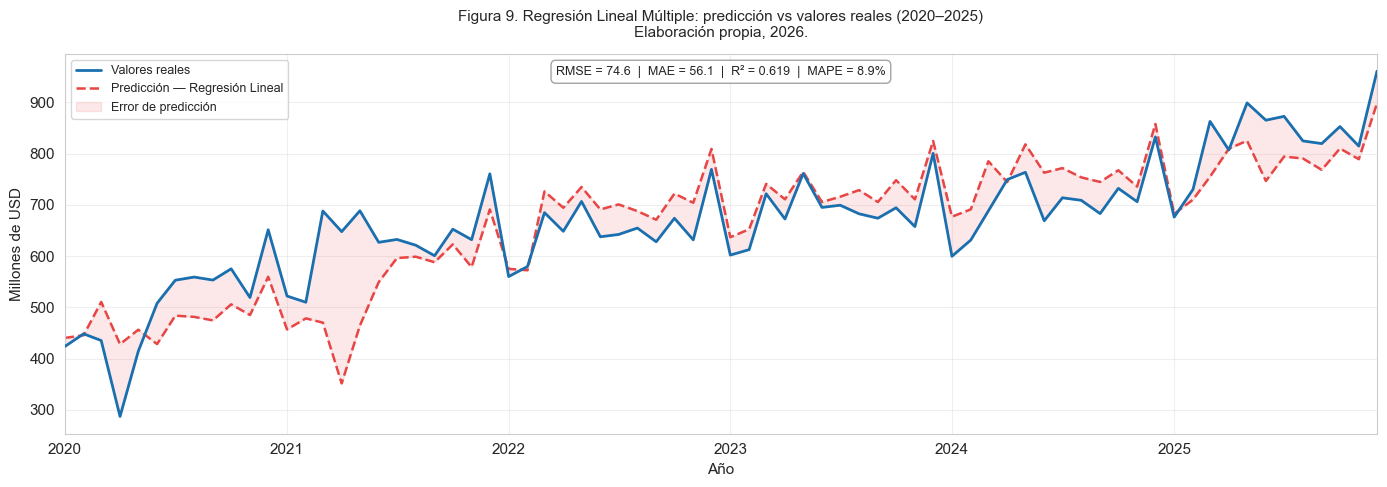

Figura 9 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura9_prediccion_regresion_lineal.png


In [8]:
# ============================================================
# 7. BLOQUE 2 — CELDA 8: GRÁFICO PREDICCIÓN VS VALORES REALES
# ============================================================
# Este gráfico muestra visualmente la capacidad del modelo
# de Regresión Lineal Múltiple para seguir la evolución de
# las remesas durante el período de prueba (2020-2025).
#
# Se utiliza el mismo formato gráfico empleado en los demás
# modelos para mantener consistencia visual en el documento.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Alinear fechas
# ----------------------------------------------------------

fechas_lr = y_test.index


# ----------------------------------------------------------
# PASO 2: Construir gráfico
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales
ax.plot(
    fechas_lr,
    y_test_orig,
    color='#1a6faf',
    linewidth=2,
    label='Valores reales',
    zorder=3
)

# Predicciones Regresión Lineal
ax.plot(
    fechas_lr,
    y_pred_lr,
    color='#e84545',
    linewidth=1.8,
    linestyle='--',
    label='Predicción — Regresión Lineal',
    zorder=2
)

# Área de error
ax.fill_between(
    fechas_lr,
    y_test_orig,
    y_pred_lr,
    alpha=0.12,
    color='#e84545',
    label='Error de predicción'
)


# ----------------------------------------------------------
# PASO 3: Mostrar métricas
# ----------------------------------------------------------

texto_metricas = (
    f"RMSE = {rmse_lr:.1f}  |  "
    f"MAE = {mae_lr:.1f}  |  "
    f"R² = {r2_lr:.3f}  |  "
    f"MAPE = {mape_lr:.1f}%"
)

ax.text(
    0.50,
    0.97,
    texto_metricas,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#999999',
        alpha=0.90
    ),
    zorder=10
)


# ----------------------------------------------------------
# PASO 4: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Figura 9. Regresión Lineal Múltiple: predicción vs valores reales (2020–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')

ax.legend(
    loc='upper left',
    fontsize=9
)

ax.set_xlim(
    fechas_lr.min(),
    fechas_lr.max()
)

ax.margins(x=0)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 5: Guardar figura
# ----------------------------------------------------------

ruta_figura9 = (
    OUTPUTS_MODELADO / 'figura9_prediccion_regresion_lineal.png'
)

plt.savefig(
    ruta_figura9,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 9 guardada: {ruta_figura9}"
)

In [9]:
# ============================================================
# 8. RANDOM FOREST - VALIDACION CRUZADA
# ============================================================
# ESTRATEGIA DE MODELADO:
#   Para Random Forest se utiliza un subconjunto de variables
#   compuesto por rezagos de remesas y variables dummy.
#
#   Esta selección prioriza información temporal directamente
#   relacionada con la dinámica histórica de la variable objetivo
#   y reduce la presencia de predictores macroeconómicos altamente
#   correlacionados identificados durante el EDA.
#
#   Los rezagos de corto plazo permiten incorporar dependencia
#   temporal reciente, mientras que Remesas_Lag12 aporta información
#   sobre patrones asociados al ciclo anual.
#
#   Las variables dummy permiten representar períodos específicos
#   definidos metodológicamente en el estudio.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Features reducidas — solo rezagos y dummies
# ----------------------------------------------------------

FEATURES_RF_V2 = [
    'Remesas_Lag1',
    'Remesas_Lag2',
    'Remesas_Lag3',
    'Remesas_Lag12',
    'Dummy_Crisis',
    'Dummy_Covid'
]
# Justificación de cada variable:
# Remesas_Lag1/2/3: incorporan información sobre la dependencia
# temporal reciente de la serie. Su inclusión es consistente con
# los patrones observados en el análisis ACF/PACF del EDA.
#
# Remesas_Lag12: incorpora información del mismo mes del año
# anterior y permite representar posibles patrones asociados
# al ciclo anual.
#
# Dummy_Crisis y Dummy_Covid: representan períodos específicos
# definidos metodológicamente en el estudio.

X_rf2 = df_modelo[FEATURES_RF_V2]
y_rf2 = df_modelo['Remesas_Millones_USD']

# División temporal
X_rf2_train = X_rf2[X_rf2.index <= FECHA_CORTE]
X_rf2_test  = X_rf2[X_rf2.index >  FECHA_CORTE]
y_rf2_train = y_rf2[y_rf2.index <= FECHA_CORTE]
y_rf2_test  = y_rf2[y_rf2.index >  FECHA_CORTE]

# Escalar
scaler_rf2 = StandardScaler()
X_rf2_train_scaled = scaler_rf2.fit_transform(X_rf2_train)
X_rf2_test_scaled  = scaler_rf2.transform(X_rf2_test)

print(f"✓ Features reducidas: {FEATURES_RF_V2}")
print(f"  Train: {X_rf2_train_scaled.shape}")
print(f"  Test : {X_rf2_test_scaled.shape}")

# ----------------------------------------------------------
# PASO 2: Modelo
# ----------------------------------------------------------

modelo_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=8,
    max_features='sqrt',
    # 'sqrt': en cada split usa raíz cuadrada del número de features.
    # Con 6 features → usa ~2-3 en cada split.
    # Más diversidad entre árboles, menos sobreajuste.
    random_state=SEED
)

# ----------------------------------------------------------
# PASO 3: Validación cruzada
# ----------------------------------------------------------

rmse_cv_rf = []
mae_cv_rf  = []
r2_cv_rf   = []

print("\nValidación cruzada Random Forest (features reducidas):")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_rf2_train_scaled), 1):

    X_fold_train = X_rf2_train_scaled[train_idx]
    X_fold_val   = X_rf2_train_scaled[val_idx]
    y_fold_train = y_rf2_train.values[train_idx]
    y_fold_val   = y_rf2_train.values[val_idx]

    modelo_rf.fit(X_fold_train, y_fold_train)
    y_pred_fold = modelo_rf.predict(X_fold_val)

    rmse_fold = np.sqrt(mean_squared_error(y_fold_val, y_pred_fold))
    mae_fold  = mean_absolute_error(y_fold_val, y_pred_fold)
    r2_fold   = r2_score(y_fold_val, y_pred_fold)

    rmse_cv_rf.append(rmse_fold)
    mae_cv_rf.append(mae_fold)
    r2_cv_rf.append(r2_fold)

    print(f"  Fold {fold}: RMSE={rmse_fold:.2f}  MAE={mae_fold:.2f}  R²={r2_fold:.4f}")

print(f"\n--- Promedio validación cruzada ---")
print(f"  RMSE : {np.mean(rmse_cv_rf):.2f} ± {np.std(rmse_cv_rf):.2f}")
print(f"  MAE  : {np.mean(mae_cv_rf):.2f} ± {np.std(mae_cv_rf):.2f}")
print(f"  R²   : {np.mean(r2_cv_rf):.4f} ± {np.std(r2_cv_rf):.4f}")

✓ Features reducidas: ['Remesas_Lag1', 'Remesas_Lag2', 'Remesas_Lag3', 'Remesas_Lag12', 'Dummy_Crisis', 'Dummy_Covid']
  Train: (336, 6)
  Test : (72, 6)

Validación cruzada Random Forest (features reducidas):
  Fold 1: RMSE=35.38  MAE=28.93  R²=-1.5956
  Fold 2: RMSE=66.79  MAE=53.28  R²=-1.7487
  Fold 3: RMSE=67.85  MAE=61.70  R²=-4.5204
  Fold 4: RMSE=32.59  MAE=24.52  R²=0.0775
  Fold 5: RMSE=91.01  MAE=75.72  R²=-1.8682

--- Promedio validación cruzada ---
  RMSE : 58.72 ± 21.99
  MAE  : 48.83 ± 19.47
  R²   : -1.9311 ± 1.4757


In [10]:
# ============================================================
# 9. RANDOM FOREST: ENTRENAMIENTO FINAL
# ============================================================

# Entrenar con todos los datos de entrenamiento
modelo_rf.fit(X_rf2_train_scaled, y_rf2_train.values)

# Predecir en test
y_pred_rf = modelo_rf.predict(X_rf2_test_scaled)

# Diagnóstico descriptivo de desempeño train vs test
y_pred_rf_train = modelo_rf.predict(X_rf2_train_scaled)
r2_train_rf = r2_score(y_rf2_train.values, y_pred_rf_train)

# Métricas en test
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_orig, y_pred_rf)
r2_rf   = r2_score(y_test_orig, y_pred_rf)
mape_rf = np.mean(np.abs((y_test_orig - y_pred_rf) / y_test_orig)) * 100

print("=== RANDOM FOREST — RESULTADOS FINALES ===")
print(f"\n  RMSE : {rmse_rf:.2f} millones USD")
print(f"  MAE  : {mae_rf:.2f} millones USD")
print(f"  R²   : {r2_rf:.4f}")
print(f"  MAPE : {mape_rf:.2f}%")
print(f"\n  R² entrenamiento : {r2_train_rf:.4f}")
print(f"  R² prueba        : {r2_rf:.4f}")
print(f"  Diferencia       : {r2_train_rf - r2_rf:.4f}")

# Primeros 6 meses para verificar visualmente
print("\n=== VERIFICACIÓN PRIMEROS 6 MESES TEST ===")
comp = pd.DataFrame({
    'Real'      : y_test_orig[:6],
    'Prediccion': y_pred_rf[:6],
    'Error_%'   : np.abs((y_test_orig[:6] - y_pred_rf[:6])
                         / y_test_orig[:6]) * 100
}, index=y_test.index[:6])
print(comp.round(1))

# Guardar métricas
metricas_modelos['Random Forest'] = {
    'RMSE': rmse_rf,
    'MAE' : mae_rf,
    'R2'  : r2_rf,
    'MAPE': mape_rf
}
print("\n Métricas guardadas para comparación final.")

=== RANDOM FOREST — RESULTADOS FINALES ===

  RMSE : 232.51 millones USD
  MAE  : 208.15 millones USD
  R²   : -2.6973
  MAPE : 29.57%

  R² entrenamiento : 0.9838
  R² prueba        : -2.6973
  Diferencia       : 3.6810

=== VERIFICACIÓN PRIMEROS 6 MESES TEST ===
             Real  Prediccion  Error_%
Fecha                                 
2020-01-01  423.8       422.7      0.2
2020-02-01  448.5       432.5      3.6
2020-03-01  435.4       438.8      0.8
2020-04-01  287.3       439.6     53.0
2020-05-01  414.4       413.2      0.3
2020-06-01  508.1       399.8     21.3

 Métricas guardadas para comparación final.


=== IMPORTANCIA DE VARIABLES — RANDOM FOREST ===
     Variable  Importancia_%
Remesas_Lag12          34.17
 Remesas_Lag1          24.23
 Remesas_Lag3          22.10
 Remesas_Lag2          19.34
 Dummy_Crisis           0.16
  Dummy_Covid           0.00


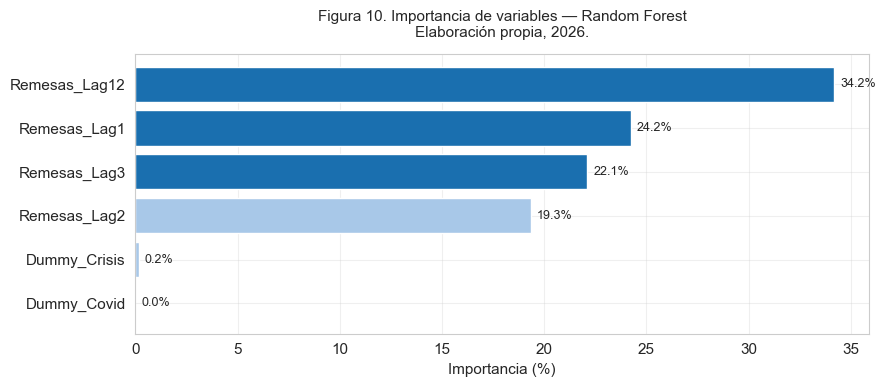

Tabla exportada: C:\Users\kmabe\TFM\outputs_modelado\tabla_importancia_rf.csv
Figura 10 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura10_importancia_rf.png


In [11]:
# ============================================================
# 10. RANDOM FOREST - IMPORTANCIA DE VARIABLES
# ============================================================
# Se usa FEATURES_RF_V2 porque el modelo final de Random Forest
# fue entrenado con las 6 features reducidas (rezagos + dummies),
# no con el conjunto completo de 14 variables.
# ============================================================

importancias_rf = pd.DataFrame({
    'Variable':    FEATURES_RF_V2,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

importancias_rf['Importancia_%'] = (
    importancias_rf['Importancia'] * 100).round(2)

print("=== IMPORTANCIA DE VARIABLES — RANDOM FOREST ===")
print(importancias_rf[['Variable', 'Importancia_%']].to_string(index=False))

# ----------------------------------------------------------
# Exportar tabla de importancia
# ----------------------------------------------------------
ruta_tabla_importancia_rf = (
    OUTPUTS_MODELADO / 'tabla_importancia_rf.csv'
)

importancias_rf.to_csv(
    ruta_tabla_importancia_rf,
    index=False
)

# ----------------------------------------------------------
# Gráfico de importancia
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

colores = ['#1a6faf' if i < 3 else '#a8c8e8'
           for i in range(len(importancias_rf))]

ax.barh(importancias_rf['Variable'],
        importancias_rf['Importancia_%'],
        color=colores, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Importancia (%)')
ax.set_title(
    'Figura 10. Importancia de variables — Random Forest\n'
    'Elaboración propia, 2026.',
    fontsize=11, pad=12)

for i, val in enumerate(importancias_rf['Importancia_%']):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()

# ----------------------------------------------------------
# Exportar Figura 10
# ----------------------------------------------------------
ruta_figura10 = (
    OUTPUTS_MODELADO / 'figura10_importancia_rf.png'
)

plt.savefig(
    ruta_figura10,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f"Tabla exportada: {ruta_tabla_importancia_rf}")
print(f"Figura 10 guardada: {ruta_figura10}")

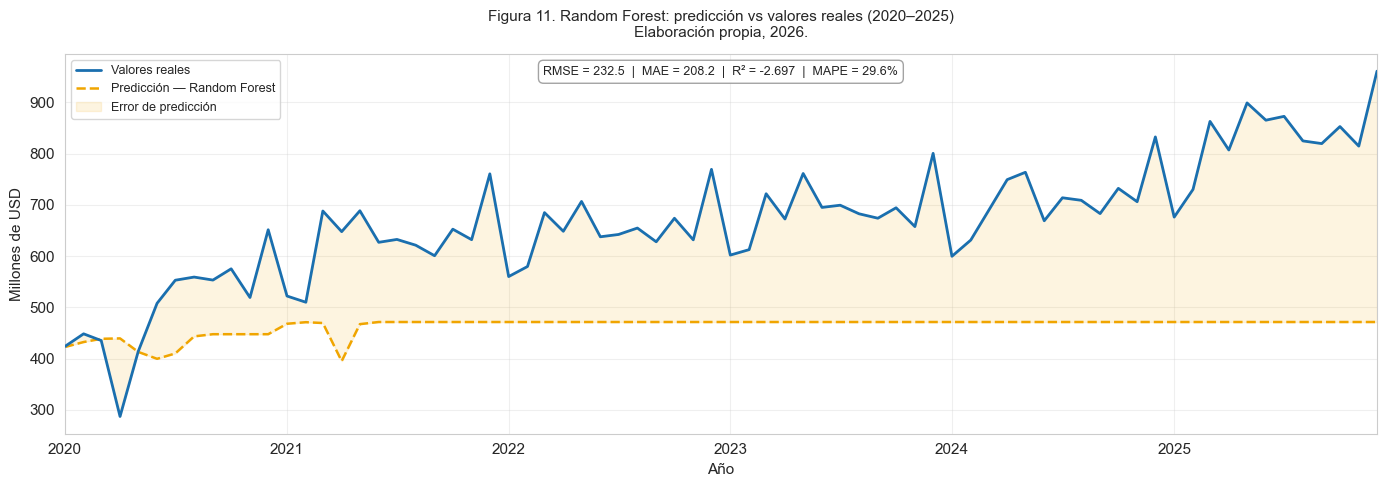

Figura 11 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura11_prediccion_rf.png


In [12]:
# ============================================================
# 11. RANDOM FOREST: GRÁFICO PREDICCIÓN VS VALORES REALES
# ============================================================
# Este gráfico muestra visualmente la capacidad del modelo
# Random Forest para seguir la evolución de las remesas
# durante el período de prueba (2020-2025).
#
# Se utiliza el mismo formato gráfico empleado en los demás
# modelos para mantener consistencia visual en el documento.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Alinear fechas
# ----------------------------------------------------------

fechas_rf = y_test.index


# ----------------------------------------------------------
# PASO 2: Construir gráfico
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales
ax.plot(
    fechas_rf,
    y_test_orig,
    color='#1a6faf',
    linewidth=2,
    label='Valores reales',
    zorder=3
)

# Predicciones Random Forest
ax.plot(
    fechas_rf,
    y_pred_rf,
    color='#f0a500',
    linewidth=1.8,
    linestyle='--',
    label='Predicción — Random Forest',
    zorder=2
)

# Área de error
ax.fill_between(
    fechas_rf,
    y_test_orig,
    y_pred_rf,
    alpha=0.12,
    color='#f0a500',
    label='Error de predicción'
)


# ----------------------------------------------------------
# PASO 3: Mostrar métricas
# ----------------------------------------------------------

texto_metricas = (
    f"RMSE = {rmse_rf:.1f}  |  "
    f"MAE = {mae_rf:.1f}  |  "
    f"R² = {r2_rf:.3f}  |  "
    f"MAPE = {mape_rf:.1f}%"
)

ax.text(
    0.50,
    0.97,
    texto_metricas,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#999999',
        alpha=0.90
    ),
    zorder=10
)


# ----------------------------------------------------------
# PASO 4: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Figura 11. Random Forest: predicción vs valores reales (2020–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')

ax.legend(
    loc='upper left',
    fontsize=9
)

ax.set_xlim(
    fechas_rf.min(),
    fechas_rf.max()
)

ax.margins(x=0)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 5: Guardar figura
# ----------------------------------------------------------

ruta_figura11 = (
    OUTPUTS_MODELADO / 'figura11_prediccion_rf.png'
)

plt.savefig(
    ruta_figura11,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 11 guardada: {ruta_figura11}"
)

In [13]:
# ============================================================
# 12. XGBOOST CON VALIDACIÓN CRUZADA
# ============================================================
# XGBoost (Extreme Gradient Boosting) construye árboles de forma
# secuencial, donde cada nueva etapa busca reducir los errores
# residuales acumulados por el modelo.
#
# Entre sus características se encuentran:
#   - Capacidad para modelar relaciones no lineales.
#   - Mecanismos de regularización.
#   - Control de complejidad mediante hiperparámetros.
#   - Submuestreo de observaciones y variables.
#
# Al igual que otros modelos basados en árboles, su capacidad
# de generalización puede verse afectada cuando el período de
# prueba presenta patrones diferentes a los observados durante
# el entrenamiento.
#
# Hiperparámetros principales:
#   n_estimators  : número de árboles secuenciales
#   max_depth     : profundidad máxima de cada árbol
#   learning_rate : cuánto corrige cada árbol nuevo (eta)
#                   valores bajos + más árboles = más preciso
#   subsample     : fracción de datos usada por cada árbol
#   colsample_bytree: fracción de features usada por cada árbol
#   reg_lambda    : regularización L2 (reduce sobreajuste)
#   reg_alpha     : regularización L1 (puede eliminar features poco útiles)
# ============================================================

# ----------------------------------------------------------
# PASO 1: Definir el modelo
# ----------------------------------------------------------

modelo_xgb = XGBRegressor(
    n_estimators=500,
    # Número de etapas de boosting utilizadas por el modelo.
    # Su efecto depende de la interacción con otros hiperparámetros,
    # especialmente la tasa de aprendizaje.

    max_depth=4,
    # Árboles poco profundos para evitar sobreajuste.
    # Con 336 observaciones de train, profundidad 4 es suficiente.

    learning_rate=0.05,
    # Controla la contribución de cada nueva etapa de boosting.
    # Valores bajos producen actualizaciones más graduales y suelen
    # combinarse con un mayor número de estimadores.

    subsample=0.8,
    # Cada árbol usa el 80% de las observaciones elegidas al azar.
    # Introduce variedad y reduce sobreajuste.

    colsample_bytree=0.8,
    # Cada árbol usa el 80% de las features elegidas al azar.
    # Similar al max_features de Random Forest.

    reg_lambda=2.0,
    # Regularización L2: penaliza coeficientes grandes.
    # Valor alto = modelo más conservador = menos sobreajuste.

    reg_alpha=0.5,
    # Regularización L1: puede llevar algunos pesos a cero.
    # Ayuda cuando hay features poco relevantes.

    random_state=SEED,
    verbosity=0
    # verbosity=0: silencia los mensajes de entrenamiento.
)

print(" Modelo XGBoost definido.")

# ----------------------------------------------------------
# PASO 2: Definir conjunto de variables
# ----------------------------------------------------------
# Para XGBoost se utiliza el conjunto completo de features
# definido previamente en el notebook.
#
# Esta configuración permite evaluar el modelo utilizando
# tanto variables macroeconómicas como rezagos y variables dummy.
# X_train_scaled y X_test_scaled fueron definidos previamente.

# ----------------------------------------------------------
# PASO 3: Validación cruzada temporal
# ----------------------------------------------------------

rmse_cv_xgb = []
mae_cv_xgb  = []
r2_cv_xgb   = []

print("\nValidación cruzada XGBoost:")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):

    X_fold_train = X_train_scaled[train_idx]
    X_fold_val   = X_train_scaled[val_idx]
    y_fold_train = y_train.values[train_idx]
    y_fold_val   = y_train.values[val_idx]
    # XGBoost trabaja directamente con y en escala original,
    # igual que Random Forest.

    modelo_xgb.fit(
        X_fold_train, y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
        # eval_set: XGBoost monitorea el error en validación
        # durante el entrenamiento de cada fold.
        # verbose=False: no imprime el progreso árbol por árbol.
    )

    y_pred_fold = modelo_xgb.predict(X_fold_val)

    rmse_fold = np.sqrt(mean_squared_error(y_fold_val, y_pred_fold))
    mae_fold  = mean_absolute_error(y_fold_val, y_pred_fold)
    r2_fold   = r2_score(y_fold_val, y_pred_fold)

    rmse_cv_xgb.append(rmse_fold)
    mae_cv_xgb.append(mae_fold)
    r2_cv_xgb.append(r2_fold)

    print(f"  Fold {fold}: RMSE={rmse_fold:.2f}  MAE={mae_fold:.2f}  R²={r2_fold:.4f}")

print(f"\n--- Promedio validación cruzada XGBoost (5 folds) ---")
print(f"  RMSE : {np.mean(rmse_cv_xgb):.2f} ± {np.std(rmse_cv_xgb):.2f}")
print(f"  MAE  : {np.mean(mae_cv_xgb):.2f} ± {np.std(mae_cv_xgb):.2f}")
print(f"  R²   : {np.mean(r2_cv_xgb):.4f} ± {np.std(r2_cv_xgb):.4f}")

 Modelo XGBoost definido.

Validación cruzada XGBoost:
  Fold 1: RMSE=33.19  MAE=26.88  R²=-1.2852
  Fold 2: RMSE=67.73  MAE=55.06  R²=-1.8271
  Fold 3: RMSE=28.43  MAE=23.52  R²=0.0305
  Fold 4: RMSE=56.20  MAE=44.72  R²=-1.7442
  Fold 5: RMSE=78.57  MAE=63.90  R²=-1.1379

--- Promedio validación cruzada XGBoost (5 folds) ---
  RMSE : 52.83 ± 19.37
  MAE  : 42.81 ± 15.65
  R²   : -1.1928 ± 0.6655


In [14]:
# ============================================================
# 13. XGBOOST - ENTRENAMIENTO FINAL Y MÉTRICAS
# ============================================================

# Entrenar con todos los datos de entrenamiento
modelo_xgb.fit(X_train_scaled, y_train.values)

# Predecir en test
y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Diagnóstico descriptivo de desempeño train vs test
y_pred_xgb_train = modelo_xgb.predict(X_train_scaled)
r2_train_xgb = r2_score(y_train.values, y_pred_xgb_train)

# Métricas en test
rmse_xgb = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test_orig, y_pred_xgb)
r2_xgb   = r2_score(y_test_orig, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test_orig - y_pred_xgb) / y_test_orig)) * 100

print("=== XGBOOST — RESULTADOS EN CONJUNTO DE PRUEBA ===")
print(f"\n  RMSE : {rmse_xgb:.2f} millones USD")
print(f"  MAE  : {mae_xgb:.2f} millones USD")
print(f"  R²   : {r2_xgb:.4f}")
print(f"  MAPE : {mape_xgb:.2f}%")
print(f"\n  R² entrenamiento : {r2_train_xgb:.4f}")
print(f"  R² prueba        : {r2_xgb:.4f}")
print(f"  Diferencia       : {r2_train_xgb - r2_xgb:.4f}")

# Guardar métricas
metricas_modelos['XGBoost'] = {
    'RMSE': rmse_xgb,
    'MAE' : mae_xgb,
    'R2'  : r2_xgb,
    'MAPE': mape_xgb
}
print("\n Métricas guardadas para comparación final.")

=== XGBOOST — RESULTADOS EN CONJUNTO DE PRUEBA ===

  RMSE : 220.52 millones USD
  MAE  : 196.79 millones USD
  R²   : -2.3258
  MAPE : 28.26%

  R² entrenamiento : 0.9997
  R² prueba        : -2.3258
  Diferencia       : 3.3255

 Métricas guardadas para comparación final.


=== IMPORTANCIA DE VARIABLES — XGBOOST ===
            Variable  Importancia_%
       Remesas_Lag12      42.139999
    Inflacion_CPI_US      38.349998
 Salario_Promedio_US      15.310000
              PIB_US       1.220000
        Remesas_Lag1       0.790000
        Dummy_Crisis       0.700000
Desempleo_General_US       0.270000
 Deportaciones_Total       0.250000
        Remesas_Lag3       0.220000
Desempleo_Hispano_US       0.210000
        Remesas_Lag2       0.210000
        Inflacion_ES       0.180000
              PIB_ES       0.160000
         Dummy_Covid       0.000000


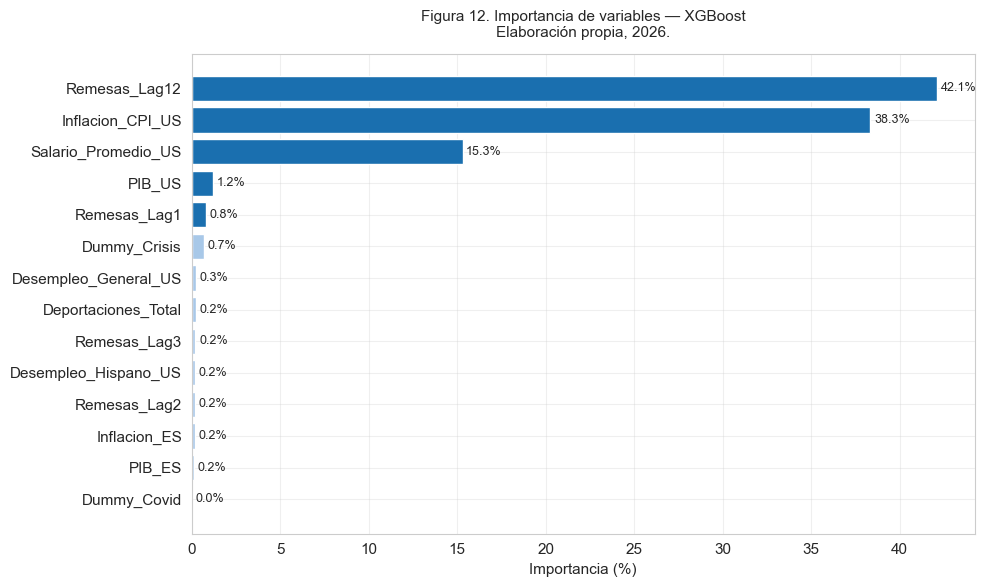

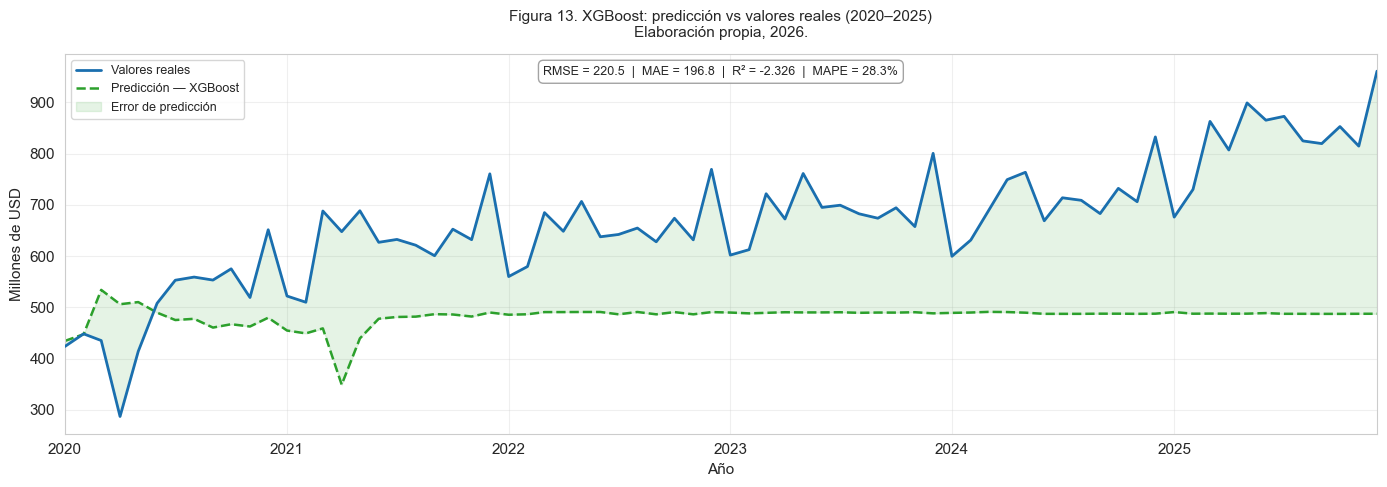

Tabla exportada: C:\Users\kmabe\TFM\outputs_modelado\tabla_importancia_xgb.csv
Figura 12 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura12_importancia_xgb.png
Figura 13 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura13_prediccion_xgb.png


In [15]:
# ============================================================
# 14. XGBOOST - IMPORTANCIA Y GRÁFICO DE PREDICCIÓN
# ============================================================

# ----------------------------------------------------------
# Importancia de variables XGBoost
# ----------------------------------------------------------
# XGBoost proporciona medidas de importancia de variables
# derivadas de la contribución de los predictores al modelo.
#
# En esta celda se utiliza el atributo feature_importances_
# del modelo entrenado para obtener una medida relativa de
# importancia y facilitar la comparación entre variables.
#
# Estas importancias son descriptivas del modelo ajustado
# y no implican relaciones causales.

importancias_xgb = pd.DataFrame({
    'Variable'   : FEATURES,
    'Importancia': modelo_xgb.feature_importances_
}).sort_values(
    'Importancia',
    ascending=False
).reset_index(drop=True)

importancias_xgb['Importancia_%'] = (
    importancias_xgb['Importancia'] * 100
).round(2)

print("=== IMPORTANCIA DE VARIABLES — XGBOOST ===")

print(
    importancias_xgb[
        ['Variable', 'Importancia_%']
    ].to_string(index=False)
)

# ----------------------------------------------------------
# Exportar tabla de importancia
# ----------------------------------------------------------

ruta_tabla_importancia_xgb = (
    OUTPUTS_MODELADO / 'tabla_importancia_xgb.csv'
)

importancias_xgb.to_csv(
    ruta_tabla_importancia_xgb,
    index=False
)


# ----------------------------------------------------------
# Gráfico importancia
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

colores_xgb = [
    '#1a6faf' if i < 5 else '#a8c8e8'
    for i in range(len(importancias_xgb))
]

ax.barh(
    importancias_xgb['Variable'],
    importancias_xgb['Importancia_%'],
    color=colores_xgb,
    edgecolor='white'
)

ax.invert_yaxis()

ax.set_xlabel('Importancia (%)')

ax.set_title(
    'Figura 12. Importancia de variables — XGBoost\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

for i, val in enumerate(
    importancias_xgb['Importancia_%']
):
    ax.text(
        val + 0.2,
        i,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()

# ----------------------------------------------------------
# Exportar Figura 12
# ----------------------------------------------------------

ruta_figura12 = (
    OUTPUTS_MODELADO / 'figura12_importancia_xgb.png'
)

plt.savefig(
    ruta_figura12,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# XGBOOST: GRÁFICO PREDICCIÓN VS VALORES REALES
# ============================================================
# Este gráfico muestra visualmente la capacidad del modelo
# XGBoost para seguir la evolución de las remesas durante
# el período de prueba (2020-2025).
#
# Se utiliza el mismo formato gráfico empleado en los demás
# modelos para mantener consistencia visual en el documento.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Alinear fechas
# ----------------------------------------------------------

fechas_xgb = y_test.index


# ----------------------------------------------------------
# PASO 2: Construir gráfico
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales
ax.plot(
    fechas_xgb,
    y_test_orig,
    color='#1a6faf',
    linewidth=2,
    label='Valores reales',
    zorder=3
)

# Predicciones XGBoost
ax.plot(
    fechas_xgb,
    y_pred_xgb,
    color='#2ca02c',
    linewidth=1.8,
    linestyle='--',
    label='Predicción — XGBoost',
    zorder=2
)

# Área de error
ax.fill_between(
    fechas_xgb,
    y_test_orig,
    y_pred_xgb,
    alpha=0.12,
    color='#2ca02c',
    label='Error de predicción'
)


# ----------------------------------------------------------
# PASO 3: Mostrar métricas
# ----------------------------------------------------------

texto_metricas = (
    f"RMSE = {rmse_xgb:.1f}  |  "
    f"MAE = {mae_xgb:.1f}  |  "
    f"R² = {r2_xgb:.3f}  |  "
    f"MAPE = {mape_xgb:.1f}%"
)

ax.text(
    0.50,
    0.97,
    texto_metricas,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#999999',
        alpha=0.90
    ),
    zorder=10
)


# ----------------------------------------------------------
# PASO 4: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Figura 13. XGBoost: predicción vs valores reales (2020–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')

ax.legend(
    loc='upper left',
    fontsize=9
)

ax.set_xlim(
    fechas_xgb.min(),
    fechas_xgb.max()
)

ax.margins(x=0)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 5: Guardar figura
# ----------------------------------------------------------

ruta_figura13 = (
    OUTPUTS_MODELADO / 'figura13_prediccion_xgb.png'
)

plt.savefig(
    ruta_figura13,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f"Tabla exportada: {ruta_tabla_importancia_xgb}")
print(f"Figura 12 guardada: {ruta_figura12}")
print(f"Figura 13 guardada: {ruta_figura13}")

In [16]:
# ============================================================
# 15. LSTM
# ============================================================
#
# Este bloque implementa una red neuronal recurrente Long
# Short-Term Memory (LSTM) para modelar la dinámica temporal
# de las remesas familiares.
#
# A diferencia de los modelos anteriores, el LSTM utiliza
# secuencias de observaciones históricas para capturar
# dependencias temporales de largo plazo.
#
# La evaluación se realiza sobre el mismo período de prueba
# utilizado en los demás modelos (2020–2025) para garantizar
# comparabilidad metodológica.
# ============================================================

# ============================================================
# LSTM: PREPARACIÓN DE DATOS PARA LSTM
# ============================================================
# Las redes neuronales requieren que las variables estén
# escaladas a rangos similares para facilitar el proceso
# de optimización.
#
# Además, un modelo LSTM no trabaja con observaciones
# individuales, sino con secuencias temporales.
#
# En este estudio se utiliza una ventana de 12 meses,
# permitiendo que el modelo observe un año completo de
# información antes de generar cada predicción.
#
# Para conservar las 72 observaciones del período de prueba,
# las secuencias de test utilizan como contexto inicial los
# últimos 12 meses del conjunto de entrenamiento.
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# ----------------------------------------------------------
# PASO 1: Escalar variables
# ----------------------------------------------------------

scaler_X_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

# Ajustar los escaladores únicamente con entrenamiento
X_train_scaled_lstm = scaler_X_lstm.fit_transform(
    X_train
)

y_train_scaled_lstm = scaler_y_lstm.fit_transform(
    y_train.values.reshape(-1, 1)
)

# Transformar test usando exclusivamente los parámetros
# aprendidos a partir del conjunto de entrenamiento
X_test_scaled_lstm = scaler_X_lstm.transform(
    X_test
)

y_test_scaled_lstm = scaler_y_lstm.transform(
    y_test.values.reshape(-1, 1)
)

# ----------------------------------------------------------
# PASO 2: Crear secuencias temporales
# ----------------------------------------------------------

WINDOW = 12

def crear_secuencias(X, y, window):

    X_seq = []
    y_seq = []

    for i in range(window, len(X)):
        X_seq.append(
            X[i-window:i]
        )
        y_seq.append(
            y[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

# Secuencias de entrenamiento
X_train_seq, y_train_seq = crear_secuencias(
    X_train_scaled_lstm,
    y_train_scaled_lstm,
    WINDOW
)

# ----------------------------------------------------------
# PASO 3: Preparar contexto histórico para test
# ----------------------------------------------------------
# Se concatenan los últimos 12 meses de entrenamiento con
# las 72 observaciones del conjunto de prueba.
#
# Los meses de entrenamiento se utilizan únicamente como
# contexto histórico de entrada. Las variables objetivo
# evaluadas corresponden exclusivamente al período 2020-2025.

X_test_contexto_lstm = np.vstack([
    X_train_scaled_lstm[-WINDOW:],
    X_test_scaled_lstm
])

y_test_contexto_lstm = np.vstack([
    y_train_scaled_lstm[-WINDOW:],
    y_test_scaled_lstm
])

# ----------------------------------------------------------
# PASO 4: Crear secuencias de prueba
# ----------------------------------------------------------

X_test_seq, y_test_seq = crear_secuencias(
    X_test_contexto_lstm,
    y_test_contexto_lstm,
    WINDOW
)

# ----------------------------------------------------------
# PASO 5: Verificación
# ----------------------------------------------------------

print("=== PREPARACIÓN LSTM ===")

print("\nEntrenamiento:")
print(
    f"  X_train_seq : "
    f"{X_train_seq.shape}"
)
print(
    f"  y_train_seq : "
    f"{y_train_seq.shape}"
)

print("\nPrueba:")
print(
    f"  X_test_seq  : "
    f"{X_test_seq.shape}"
)
print(
    f"  y_test_seq  : "
    f"{y_test_seq.shape}"
)

print(
    f"\nVentana utilizada: "
    f"{WINDOW} meses"
)

print(
    f"Predicciones de prueba disponibles: "
    f"{len(y_test_seq)}"
)

assert len(y_test_seq) == len(y_test), (
    "ERROR: la cantidad de secuencias LSTM de prueba "
    "no coincide con las observaciones del conjunto test."
)

print(
    "\nVerificación superada: el LSTM conserva "
    "las 72 observaciones de prueba."
)

=== PREPARACIÓN LSTM ===

Entrenamiento:
  X_train_seq : (324, 12, 14)
  y_train_seq : (324, 1)

Prueba:
  X_test_seq  : (72, 12, 14)
  y_test_seq  : (72, 1)

Ventana utilizada: 12 meses
Predicciones de prueba disponibles: 72

Verificación superada: el LSTM conserva las 72 observaciones de prueba.


In [17]:
# ============================================================
# 16. LSTM: DEFINICIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================
# Se utiliza una arquitectura simple compuesta por:
#
#   - Una capa de entrada explícita
#   - Una capa LSTM de 50 unidades
#   - Una capa Dropout para reducir sobreajuste
#   - Una capa Dense de salida
#
# Para favorecer la reproducibilidad del experimento se fija
# una semilla global antes de construir el modelo y se activan,
# cuando están disponibles, operaciones deterministas.
#
# EarlyStopping detiene automáticamente el entrenamiento
# cuando la pérdida de validación deja de mejorar.
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ----------------------------------------------------------
# PASO 1: Reiniciar estado y fijar reproducibilidad
# ----------------------------------------------------------

SEED = 42

tf.keras.backend.clear_session()

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Fija de forma coordinada las semillas de Python,
# NumPy y TensorFlow/Keras
tf.keras.utils.set_random_seed(SEED)

# Solicitar operaciones deterministas cuando estén disponibles
try:
    tf.config.experimental.enable_op_determinism()
    print("Determinismo de TensorFlow activado.")
except Exception as e:
    print(
        "No fue posible activar determinismo estricto:",
        str(e)
    )


# ----------------------------------------------------------
# PASO 2: Definir arquitectura
# ----------------------------------------------------------

modelo_lstm = Sequential([
    Input(
        shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),
    LSTM(
        units=50
    ),
    Dropout(0.20),
    Dense(1)
])


# ----------------------------------------------------------
# PASO 3: Compilar modelo
# ----------------------------------------------------------

modelo_lstm.compile(
    optimizer="adam",
    loss="mse"
)

print("\n=== ARQUITECTURA DEL MODELO ===")
modelo_lstm.summary()


# ----------------------------------------------------------
# PASO 4: Configurar Early Stopping
# ----------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# ----------------------------------------------------------
# PASO 5: Entrenamiento
# ----------------------------------------------------------

history = modelo_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)


# ----------------------------------------------------------
# PASO 6: Verificación del entrenamiento
# ----------------------------------------------------------

print("\nEntrenamiento completado.")

print(
    f"Épocas ejecutadas: "
    f"{len(history.history['loss'])}"
)


Determinismo de TensorFlow activado.

=== ARQUITECTURA DEL MODELO ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          13,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,051 (50.98 KB)

 Trainable params: 13,051 (50.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0265 - val_loss: 0.0801
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0510 - val_loss: 0.0293
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0246 - val_loss: 0.0155
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0137 - val_loss: 0.0155
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0087 - val_loss: 0.0118
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0081 - val_loss: 0.0091
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0082 - val_loss: 0.0090
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0078 - val_loss: 0.0092
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0056 - val_loss: 0.0085
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0086
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

In [18]:
# ============================================================
# 17. LSTM: PREDICCIONES Y EVALUACIÓN
# ============================================================
# Una vez entrenado el modelo, se generan predicciones sobre
# el conjunto de prueba y se calculan las mismas métricas
# utilizadas en los modelos anteriores:
#
#   • RMSE
#   • MAE
#   • R²
#   • MAPE
#
# La evaluación comprende las 72 observaciones mensuales
# del período 2020-2025.
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ----------------------------------------------------------
# PASO 1: Generar predicciones
# ----------------------------------------------------------

y_pred_scaled_lstm = modelo_lstm.predict(
    X_test_seq,
    verbose=0
)


# ----------------------------------------------------------
# PASO 2: Regresar a escala original
# ----------------------------------------------------------

y_pred_lstm = scaler_y_lstm.inverse_transform(
    y_pred_scaled_lstm
).ravel()

y_real_lstm = scaler_y_lstm.inverse_transform(
    y_test_seq
).ravel()


# ----------------------------------------------------------
# PASO 3: Verificar dimensiones
# ----------------------------------------------------------

assert len(y_real_lstm) == len(y_pred_lstm), (
    "ERROR: la cantidad de valores reales y predicciones "
    "LSTM no coincide."
)

assert len(y_real_lstm) == len(y_test), (
    "ERROR: la evaluación LSTM no conserva las 72 "
    "observaciones del conjunto de prueba."
)


# ----------------------------------------------------------
# PASO 4: Calcular métricas
# ----------------------------------------------------------

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_real_lstm,
        y_pred_lstm
    )
)

mae_lstm = mean_absolute_error(
    y_real_lstm,
    y_pred_lstm
)

r2_lstm = r2_score(
    y_real_lstm,
    y_pred_lstm
)

mape_lstm = (
    np.mean(
        np.abs(
            (
                y_real_lstm - y_pred_lstm
            )
            / y_real_lstm
        )
    )
    * 100
)


# ----------------------------------------------------------
# PASO 5: Mostrar resultados
# ----------------------------------------------------------

print(
    "=== LSTM — RESULTADOS EN "
    "CONJUNTO DE PRUEBA ==="
)

print(
    f"\nPredicciones evaluadas : "
    f"{len(y_real_lstm)}"
)

print(
    f"RMSE : "
    f"{rmse_lstm:.2f} millones USD"
)

print(
    f"MAE  : "
    f"{mae_lstm:.2f} millones USD"
)

print(
    f"R²   : "
    f"{r2_lstm:.4f}"
)

print(
    f"MAPE : "
    f"{mape_lstm:.2f}%"
)

# ----------------------------------------------------------
# PASO 6: Guardar métricas para comparación final
# ----------------------------------------------------------

metricas_modelos['LSTM'] = {
    'RMSE': rmse_lstm,
    'MAE' : mae_lstm,
    'R2'  : r2_lstm,
    'MAPE': mape_lstm
}

print("\nMétricas LSTM guardadas para comparación final.")

=== LSTM — RESULTADOS EN CONJUNTO DE PRUEBA ===

Predicciones evaluadas : 72
RMSE : 192.81 millones USD
MAE  : 177.20 millones USD
R²   : -1.5425
MAPE : 26.18%

Métricas LSTM guardadas para comparación final.


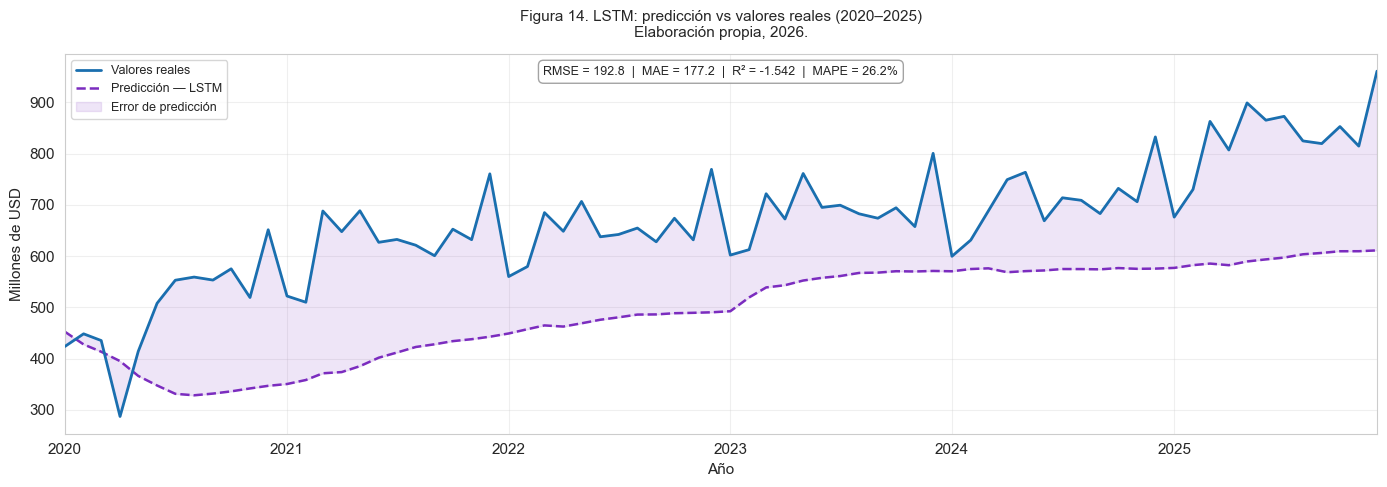

Figura 14 guardada: C:\Users\kmabe\TFM\outputs_modelado\figura14_prediccion_lstm.png


In [19]:
# ============================================================
# 18. LSTM: GRÁFICO PREDICCIÓN VS VALORES REALES
# ============================================================
# Este gráfico muestra visualmente la capacidad del modelo
# LSTM para seguir la evolución de las remesas durante el
# período de prueba (2020-2025).
#
# Se utiliza el mismo formato gráfico empleado en los demás
# modelos para mantener consistencia visual en el documento.
# ============================================================

# ----------------------------------------------------------
# PASO 1: Alinear fechas
# ----------------------------------------------------------
# Las secuencias de prueba utilizan los últimos 12 meses del
# conjunto de entrenamiento como contexto histórico.
#
# Por tanto, se conserva una predicción para cada una de las
# 72 observaciones del período de prueba 2020-2025.

fechas_lstm = y_test.index


# ----------------------------------------------------------
# PASO 2: Construir gráfico
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales
ax.plot(
    fechas_lstm,
    y_real_lstm,
    color='#1a6faf',
    linewidth=2,
    label='Valores reales',
    zorder=3
)

# Predicciones LSTM
ax.plot(
    fechas_lstm,
    y_pred_lstm,
    color='#7b2cbf',
    linewidth=1.8,
    linestyle='--',
    label='Predicción — LSTM',
    zorder=2
)

# Área de error
ax.fill_between(
    fechas_lstm,
    y_real_lstm,
    y_pred_lstm,
    alpha=0.12,
    color='#7b2cbf',
    label='Error de predicción'
)


# ----------------------------------------------------------
# PASO 3: Mostrar métricas
# ----------------------------------------------------------

texto_metricas = (
    f"RMSE = {rmse_lstm:.1f}  |  "
    f"MAE = {mae_lstm:.1f}  |  "
    f"R² = {r2_lstm:.3f}  |  "
    f"MAPE = {mape_lstm:.1f}%"
)

ax.text(
    0.50,
    0.97,
    texto_metricas,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#999999',
        alpha=0.90
    ),
    zorder=10
)


# ----------------------------------------------------------
# PASO 4: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Figura 14. LSTM: predicción vs valores reales (2020–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')

ax.legend(
    loc='upper left',
    fontsize=9
)

ax.set_xlim(
    fechas_lstm.min(),
    fechas_lstm.max()
)

ax.margins(x=0)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 5: Guardar figura
# ----------------------------------------------------------

ruta_figura14 = (
    OUTPUTS_MODELADO / 'figura14_prediccion_lstm.png'
)

plt.savefig(
    ruta_figura14,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"Figura 14 guardada: {ruta_figura14}"
)

In [20]:
# ============================================================
# 19. EXPORTACIÓN DE MÉTRICAS PARA EL PROTOTIPO
# ============================================================
# Consolida las métricas finales de los cuatro modelos
# evaluados y exporta la tabla utilizada posteriormente
# por el Notebook 4 para la comparación integrada.
#
# Esta celda no reentrena modelos ni recalcula métricas.
# Únicamente organiza y exporta los resultados finales
# obtenidos previamente en este notebook.
# ============================================================

import pandas as pd


# ----------------------------------------------------------
# PASO 1: Validar que existan los cuatro modelos
# ----------------------------------------------------------

modelos_esperados = [
    'Regresión Lineal',
    'Random Forest',
    'XGBoost',
    'LSTM'
]

modelos_faltantes = [
    modelo
    for modelo in modelos_esperados
    if modelo not in metricas_modelos
]

if modelos_faltantes:
    raise ValueError(
        "Faltan métricas para los siguientes modelos: "
        + ", ".join(modelos_faltantes)
    )


# ----------------------------------------------------------
# PASO 2: Construir tabla comparativa
# ----------------------------------------------------------

tabla_comparacion_modelos = (
    pd.DataFrame
    .from_dict(
        metricas_modelos,
        orient='index'
    )
    .loc[
        modelos_esperados,
        ['RMSE', 'MAE', 'R2', 'MAPE']
    ]
    .reset_index()
    .rename(
        columns={
            'index': 'Modelo',
            'R2': 'R²'
        }
    )
)


# ----------------------------------------------------------
# PASO 3: Agregar metadatos de evaluación
# ----------------------------------------------------------

tabla_comparacion_modelos[
    'Período evaluación'
] = '2020-01 a 2025-12'

tabla_comparacion_modelos[
    'Observaciones'
] = 72


# ----------------------------------------------------------
# PASO 4: Ordenar columnas según el esquema del Notebook 4
# ----------------------------------------------------------

tabla_comparacion_modelos = (
    tabla_comparacion_modelos[
        [
            'Modelo',
            'RMSE',
            'MAE',
            'R²',
            'MAPE',
            'Período evaluación',
            'Observaciones'
        ]
    ]
)


# ----------------------------------------------------------
# PASO 5: Mostrar resultados
# ----------------------------------------------------------

print(
    "=== COMPARACIÓN FINAL DE MODELOS ==="
)

print(
    tabla_comparacion_modelos
    .round(
        {
            'RMSE': 2,
            'MAE': 2,
            'R²': 4,
            'MAPE': 2
        }
    )
    .to_string(
        index=False
    )
)


# ----------------------------------------------------------
# PASO 6: Exportar para Notebook 4
# ----------------------------------------------------------

ruta_salida = (
    OUTPUTS_MODELADO / 'tabla_comparacion_modelos.csv'
)

tabla_comparacion_modelos.to_csv(
    ruta_salida,
    index=False,
    encoding='utf-8-sig'
)

print(
    "\nTabla comparativa exportada correctamente:"
)

print(
    ruta_salida
)

=== COMPARACIÓN FINAL DE MODELOS ===
          Modelo   RMSE    MAE      R²  MAPE Período evaluación  Observaciones
Regresión Lineal  74.62  56.09  0.6192  8.89  2020-01 a 2025-12             72
   Random Forest 232.51 208.15 -2.6973 29.57  2020-01 a 2025-12             72
         XGBoost 220.52 196.79 -2.3258 28.26  2020-01 a 2025-12             72
            LSTM 192.81 177.20 -1.5425 26.18  2020-01 a 2025-12             72

Tabla comparativa exportada correctamente:
C:\Users\kmabe\TFM\outputs_modelado\tabla_comparacion_modelos.csv
